# RQ1 - How accurate is Intel RAPL at measuring CPU energy?
## Experiment E2 - Arrow Lake, instruction-set workload

Cells are **verbatim** from `pc2_instructiontype_expanded_withlogs.ipynb`; only the author's
absolute paths were repointed. Each cell records its original index in `metadata.provenance`.

**Read `../KNOWN_ISSUES.md` first.** Several defects were found during assembly and were
deliberately left in place so this package reproduces the published numbers.

**Inputs:** `../data/E2-arrowlake-instructions/{teensy,rapl,runinfo.pkl}`

**Paper artifacts:** Figs. `fig:energy`, `fig:energy_normalized`; Table `tableWilcox`;
appendix Tables `arrowEnergyWilcoxon` / `arrowPowerWilcoxon`.


## Data preparation


In [2]:
#this method is updated since Oct 21. A better implementation would be to skip the header, then use vectorized operation in numpy.
#binparserGraph
#binparserTemp
#temporary binary parser before we can get xml analysis working # NOT TEMPORARY ANYMORE...

import os
import struct
import pandas as pd
import numpy as np

def parse_payload(payload: bytes):
    # payload = 4B header + 8B timestamp + 70B data (14×5B entries)
    timestamp = struct.unpack('<Q', payload[4:12])[0]
    entries = payload[12:]
    data_dict = {}
    for i in range(0, len(entries), 5):
        char_id = chr(entries[i])
        value = struct.unpack('<f', entries[i+1:i+5])[0]
        data_dict[char_id] = value
    return timestamp, data_dict

def parse_binary_folder(folder_path: str):
    # 4-byte discard field, then 8-byte timestamp, then 16 × (1-byte id + 4-byte float)
    record_dtype = np.dtype([
        ('_discard', '4u1'),                 # 4 bytes
        ('timestamp', '<u8'),                # 8 bytes (uint64)
        ('pairs', [('id', 'u1'), ('data', '<f4')], (16,))  # 16 × (1+4)
    ])
    record_size = record_dtype.itemsize  # should be 92 bytes

    files = sorted(
        [f for f in os.listdir(folder_path) if f.startswith('data') and f.endswith('.bin')],
        key=lambda x: int(x[4:-4])
    )

    timestamps_all = []
    id_arrays = {i: [] for i in range(16)}  # accumulate data columns by slot
    id_chars = None                         # to hold column names (char IDs)

    for filename in files:
        path = os.path.join(folder_path, filename)

        with open(path, 'rb') as f:
            data_bytes = f.read()  # read entire file (no header)
            n_records = len(data_bytes) // record_size
            if n_records == 0:
                continue

            # vectorized read
            arr = np.frombuffer(data_bytes, dtype=record_dtype, count=n_records)

            timestamps = arr['timestamp']
            ids = arr['pairs']['id']       # shape (n_records, 16)
            vals = arr['pairs']['data']    # shape (n_records, 16)

            timestamps_all.append(timestamps)

            # verify consistent IDs per column
            first_ids = ids[0, :]
            if not np.all(ids == first_ids):
                mismatched = np.nonzero(~np.all(ids == first_ids, axis=1))[0][:5]
                print(f"\n[DEBUG] ID mismatch in file {filename}: showing first {len(mismatched)} bad rows")
                print("Expected IDs (bytes):", " ".join(f"{b:02X}" for b in first_ids))
                for idx in mismatched:
                    raw_hex = " ".join(f"{b:02X}" for b in ids[idx])
                    print(f"  Row {idx:>6}: {raw_hex}")
                raise ValueError(f"File {filename} has mixed IDs per column!")

            # store char representations once (from first file)
            if id_chars is None:
                id_chars = [chr(x) for x in first_ids]

            # accumulate per-ID arrays
            for i, id_val in enumerate(first_ids):
                id_arrays[i].append(vals[:, i])

    if not timestamps_all:
        raise ValueError("No valid records found in folder!")

    # concatenate across files
    timestamps_all = np.concatenate(timestamps_all)
    data_cols = {}
    for i, chunks in id_arrays.items():
        if len(chunks) == 0:
            continue
        colname = id_chars[i] if id_chars is not None else f"id_{i}"
        data_cols[colname] = np.concatenate(chunks)

    # Build DataFrame
    df = pd.DataFrame(data_cols)
    df.insert(0, "timestamp", timestamps_all.astype(np.uint64))

    return df

def find_rollovers(df):
    if df['timestamp'].dtype != 'uint64':
        df['timestamp'] = df['timestamp'].astype('uint64')

    # Diff using int64 to preserve exact rollover detection
    diffs = df['timestamp'].astype('int64').diff()

    rollover_points = df.index[diffs < 0].tolist()

    for idx in rollover_points:
        t_before = df.loc[idx - 1, 'timestamp']
        t_after = df.loc[idx, 'timestamp']
        print(f"Timestamp rollover at index {idx}: {t_before} → {t_after}")

    return rollover_points

# Example usage:
df = parse_binary_folder('../data/E2-arrowlake-instructions/teensy')
print(df.head(150))

print (df.iloc[12:75].head(10))

rollover = find_rollovers(df)
print(rollover)

print(df.shape)

corrected_df = df # this is just bandaid for things that still expect "corrected df"

          timestamp         A         B         C         D         H  \
0    11847837392042  2.024665  0.411796  2.196247  0.446113  2.756747   
1    11847837908042  2.058981  0.434674  2.230563  0.446113  2.676676   
2    11847838424042  2.058981  0.411796  2.207685  0.446113  2.733870   
3    11847838941042  2.001787  0.411796  2.196247  0.434674  2.699553   
4    11847839457042  2.024665  0.411796  2.196247  0.446113  2.756747   
..              ...       ...       ...       ...       ...       ...   
145  11847912366042  2.047543  0.411796  2.207685  0.434674  2.676676   
146  11847912883042  2.024665  0.388919  2.196247  0.434674  2.642359   
147  11847913399042  2.081859  0.411796  2.230563  0.446113  2.642359   
148  11847913916042  2.024665  0.411796  2.196247  0.434674  2.722431   
149  11847914432042  2.058981  0.411796  2.253441  0.434674  2.756747   

            I         J         K         Y         Z         O         P  \
0    1.086684  1.578552  0.320286  3.798809  3

In [3]:
#use this to read rapl if it's PKG, DRAM and PSYS
SAMP_PATH = "../data/E2-arrowlake-instructions/rapl"

import os
import glob
import numpy as np
import pandas as pd
import struct

import os
import glob
import numpy as np
import pandas as pd

def read_rapl_binaries(SAMP_PATH):
    """
    Reads all binary files written by flush_to_file() in C:
        fwrite(ts_buf, sizeof(int64_t), BUF_SIZE, f);
        fwrite(e_buf, sizeof(float),   BUF_SIZE, f);

    Each file contains two contiguous arrays:
        - timestamps (int64 nanoseconds)
        - energy samples (float32 joules)
    Returns a pandas DataFrame with columns ['timestamp_ns', 'energy'].
    """

    # Match pattern like rapl_YYYYMMDD_HHMMSS_###.bin
    files = sorted(glob.glob(os.path.join(SAMP_PATH, "rapl_????????_??????_???.bin")))
    if not files:
        raise FileNotFoundError(f"No RAPL binary files found in {SAMP_PATH}")

    dfs = []
    for fname in files:
        with open(fname, "rb") as f:
            raw = f.read()

        # Each file contains BUF_SIZE timestamps (8 bytes each) + BUF_SIZE floats (4 bytes each) *3
        # So total length must be divisible by 20
        if len(raw) % 20 != 0:
            raise ValueError(f"File {fname} length {len(raw)} not multiple of 20 bytes")

        # Determine number of samples
        total_bytes = len(raw)
        n_samples = total_bytes // 20

        # Split manually
        ts_bytes = raw[:n_samples * 8]
        pkg_bytes = raw[n_samples * 8 : n_samples * 12]
        dram_bytes  =  raw[n_samples * 12 : n_samples * 16 ]
        psys_bytes  = raw[n_samples * 16:]

        timestamps = np.frombuffer(ts_bytes, dtype="<u8")  # little-endian int64
        energy_pkg     = np.frombuffer(pkg_bytes,  dtype="<f4")  # little-endian float32
        energy_dram     = np.frombuffer(dram_bytes,  dtype="<f4")  # little-endian float32
        energy_psys     = np.frombuffer(psys_bytes,  dtype="<f4")  # little-endian float32


        if len(timestamps) != len(energy_pkg):
            raise ValueError(f"Timestamp and energy count mismatch in {fname}")

        df = pd.DataFrame({
            "timestamp": timestamps,
            "energy_pkg" : energy_pkg,
            "energy_dram" : energy_dram,
            "energy_psys" : energy_psys,
        })
        df["energy"] = df["energy_pkg"]
        dfs.append(df)

    # Combine all
    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

df_rapl = read_rapl_binaries(SAMP_PATH)
print(df_rapl.head(10))
print(df_rapl.shape)

        timestamp  energy_pkg  energy_dram  energy_psys    energy
0  11817130729721    0.057922          0.0          0.0  0.057922
1  11817131676212    0.000000          0.0          0.0  0.000000
2  11817132610181    0.029358          0.0          0.0  0.029358
3  11817133744396    0.024231          0.0          0.0  0.024231
4  11817134633226    0.022339          0.0          0.0  0.022339
5  11817135717780    0.000000          0.0          0.0  0.000000
6  11817136767095    0.026672          0.0          0.0  0.026672
7  11817137747185    0.023315          0.0          0.0  0.023315
8  11817138728442    0.000000          0.0          0.0  0.000000
9  11817139725948    0.021240          0.0          0.0  0.021240
(500000, 5)


Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy'], dtype='object')
2.7311633
262143.98
outliers:
             timestamp     energy_pkg  energy_dram  energy_psys         energy
22459   11839590645947  262143.984375          0.0          0.0  262143.984375
454034  12271165547517  262143.984375          0.0          0.0  262143.984375
470422  12287553537995  262143.968750          0.0          0.0  262143.968750
478607  12295738539616  262143.984375          0.0          0.0  262143.984375
494996  12312127540119  262143.968750          0.0          0.0  262143.968750
pruned 5 outliers
0.10972344
(499995, 5)
12317129522930
11817130729721
12067128535875.49
outliers:
Empty DataFrame
Columns: [timestamp, energy_pkg, energy_dram, energy_psys, energy]
Index: []
pruned 0 outliers
12067128535875.49
(499995, 5)
Found these rows duplicated observations.
             timestamp  energy_pkg  energy_dram  energy_psys    energy
12460   11829590538050    0.000000          0.0     

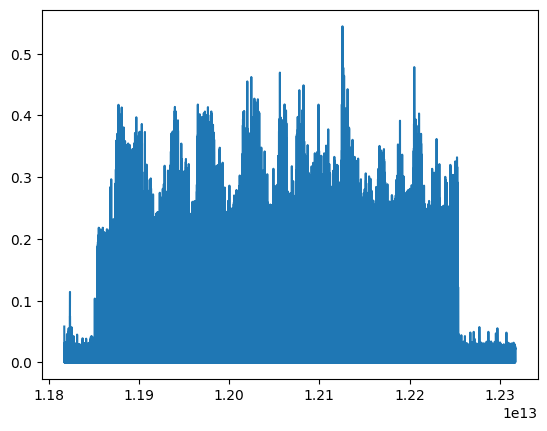

In [4]:
# data cleaning steps for RAPL
# prune outliers that look like 262143.968750, cause is unclear.
print(df_rapl.columns)
print(df_rapl["energy_pkg"].mean())
print(df_rapl["energy_pkg"].max())

df_outliers = df_rapl[df_rapl["energy_pkg"] > 200000]
print("outliers:")
print(df_outliers)

df_temp2 = df_rapl[df_rapl["energy_pkg"] < 200000]
print(f"pruned {len(df_rapl) - len(df_temp2)} outliers")
print(df_temp2["energy_pkg"].mean())
print(df_temp2.shape)

df_rapl=df_temp2

print(df_rapl["timestamp"].max())
print(df_rapl["timestamp"].min())
print(df_rapl["timestamp"].mean())

df_outliers = df_rapl[df_rapl["timestamp"] == 0]
print("outliers:")
print(df_outliers)

df_temp3 = df_rapl[df_rapl["timestamp"] != 0]
print(f"pruned {len(df_rapl) - len(df_temp3)} outliers")
print(df_temp3["timestamp"].mean())
print(df_temp3.shape)
df_rapl = df_temp3


duplicated_rows_df = df_rapl[df_rapl.duplicated(subset = ["timestamp"], keep = False)]
duplicated_rows_df = duplicated_rows_df.sort_values(by="timestamp")
print("Found these rows duplicated observations.")
print(duplicated_rows_df)
df_temp4 = df_rapl.drop_duplicates(subset=["timestamp"], keep= 'first')
print(f"dropping {len(df_rapl) - len(df_temp4)} duplicated rows")
df_rapl = df_temp4

import matplotlib.pyplot as plt
plt.plot(df_rapl["timestamp"].values,df_rapl["energy_pkg"].values)
plt.show()

In [5]:
def compute_power_from_energy(df: pd.DataFrame,
                              time_col: str = "timestamp",
                              energy_col: str = "energy") -> pd.DataFrame:
    """
    Compute instantaneous power (Watts) from cumulative energy (Joules)
    using timestamp differences in nanoseconds.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'timestamp' (ns) and 'energy' (Joule).
    time_col : str, default 'timestamp'
        Column name for timestamp (in nanoseconds).
    energy_col : str, default 'energy'
        Column name for cumulative energy (in Joules).

    Returns
    -------
    pd.DataFrame
        Copy of df with a new 'power' column (float32, in Watts).
    """
    result = df.copy()

    # Compute differences
    dE = result[energy_col]        # ΔEnergy (J)
    dT_ns = result[time_col].diff()        # ΔTime (ns)
    
    # Avoid divide-by-zero or negative intervals
    dT_ns = dT_ns.replace(0, np.nan)

    # Convert ns → seconds and compute power (Watts = J / s)
    result["power"] = (dE / (dT_ns * 1e-9)).astype("float32")

    return result

df_rapl_watt = compute_power_from_energy(df_rapl).dropna()
df_rapl_watt["dram_rapl"] = compute_power_from_energy(df_rapl, energy_col="energy_dram").dropna()["power"]
print(df_rapl_watt.shape)
print(df_rapl_watt.head(5))

(499987, 7)
        timestamp  energy_pkg  energy_dram  energy_psys    energy      power  \
1  11817131676212    0.000000          0.0          0.0  0.000000   0.000000   
2  11817132610181    0.029358          0.0          0.0  0.029358  31.433495   
3  11817133744396    0.024231          0.0          0.0  0.024231  21.363636   
4  11817134633226    0.022339          0.0          0.0  0.022339  25.132891   
5  11817135717780    0.000000          0.0          0.0  0.000000   0.000000   

   dram_rapl  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
5        0.0  


In [ ]:
# --- Trim both streams to the start of the first workload --------------------
# REPLACEMENT CELL - this is the one cell in the package that is not verbatim.
#
# The original cell 6 here subtracted a hardcoded 8,642,644,546,100 ns from the
# RAPL timestamps. That constant does not belong to this capture: applied here it
# moves RAPL to 3.17e12-3.67e12 ns against a sensor span of 11.85e12-12.32e12 ns,
# leaving the two streams with no overlap at all. The bracket merge then returns
# an empty frame and the notebook dies on the next cell with KeyError: 'Y_2'.
# See KNOWN_ISSUES.md, K3, for the evidence.
#
# No shift is applied in its place, because none is needed: on this capture the
# two streams already agree to sub-millisecond. The bracket merge matches 438,241
# of 499,993 RAPL samples inside its 500 us tolerance, which is exactly the row
# count recorded in the original notebook's own stored output.
#
# What this cell does instead is give both raw streams a common origin, by
# trimming each to start at the first workload boundary in runinfo.pkl.

# `pickle` is needed below. `scipy` is imported here too because the cells that
# originally bound it are not all present in every selection - see K9. Neither
# import changes any value; they only stop a NameError partway down.
import pickle

import scipy
import scipy.integrate
import scipy.stats

with open("../data/E2-arrowlake-instructions/runinfo.pkl", "rb") as _f:
    _workloads = pickle.load(_f)
WORKLOAD_START = _workloads[0]["start_ns"]

_n_rapl, _n_sensor = len(df_rapl_watt), len(corrected_df)
df_rapl_watt = df_rapl_watt[df_rapl_watt["timestamp"] >= WORKLOAD_START].reset_index(drop=True)
corrected_df = corrected_df[corrected_df["timestamp"] >= WORKLOAD_START].reset_index(drop=True)

print("trimmed to first workload start: {:,}".format(WORKLOAD_START))
print("  RAPL   {:,} -> {:,} rows".format(_n_rapl, len(df_rapl_watt)))
print("  sensor {:,} -> {:,} rows".format(_n_sensor, len(corrected_df)))
print("  RAPL   now spans {:,} .. {:,}".format(
    int(df_rapl_watt["timestamp"].min()), int(df_rapl_watt["timestamp"].max())))
print("  sensor now spans {:,} .. {:,}".format(
    int(corrected_df["timestamp"].min()), int(corrected_df["timestamp"].max())))


### Statistical helper: `run_tests()`


In [ ]:
# Shared helper used by the energy Wilcoxon below (parameterised by xname/yname).

import scipy.stats

def run_tests (snippet, xname= "cpu_total", yname="power"):

    prescriptive = {}
    x = snippet[xname] # measurement
    y = snippet[yname] # rapl
    

    result = scipy.stats.wilcoxon(x, y, zero_method='wilcox', correction=False, alternative='two-sided', method='auto', axis=0, nan_policy='propagate', keepdims=False)
    print(result)
    prescriptive["W twotail"] = result.statistic
    prescriptive["p twotail"] = result.pvalue # have to report this becaue no theory supporting onesided test.

    result = scipy.stats.wilcoxon(x, y, zero_method='wilcox', correction=False, alternative='less', method='auto', axis=0, nan_policy='propagate', keepdims=False)
    print(result)

    # prescriptive["W less"] = result.statistic
    # prescriptive["p less"] = result.pvalue

    result = scipy.stats.wilcoxon(x, y, zero_method='wilcox', correction=False, alternative='greater', method='auto', axis=0, nan_policy='propagate', keepdims=False)
    print(result)
    # prescriptive["W"] = result.statistic
    # prescriptive["p value"] = result.pvalue



    print("onesided Wilcoxon result: p value < threshold (ie, 0.05) means x is <alternative> than y")

    # Effect size (Rank biserial correlation)
    def calculate_directional_r(group1, group2):
        res = scipy.stats.mannwhitneyu(group1, group2, alternative='two-sided') #workaround because wilcoxon rank sum in scipy returns test statistic of X or Y depends on which one is smaller. which means we dont know the direction.
        U1 = res.statistic
        n1, n2 = len(group1), len(group2)
        
        # Calculate Rank-Biserial Correlation
        # This formula ensures: 
        # Positive r = Group 1 is greater
        # Negative r = Group 2 is greater
        r = (2 * U1 / (n1 * n2)) - 1
        
        return r, res.pvalue

    # Example
    effectsize, p = calculate_directional_r(x, y)

    print(f"effectsize {effectsize}")
    print("rB: 0: negligible effect, 0.1: small effect, 0.3: medium effect, 0.5: large effect")
    prescriptive["rank biserial effectsize"] = effectsize

    print(f"x median {x.median()}")
    print(f"y median {y.median()}")

    # mean error
    me = (x - y).mean()
    print(me)
    prescriptive["me"] = me
    # mean absolute error
    mae = (x - y).abs().mean()
    print(mae)
    prescriptive["mae"] = mae

    prescriptive["xname"] = xname
    prescriptive["yname"] = yname 
    return prescriptive


## Energy analysis: RAPL vs sensor per 100 ms window


[{'name': 'w1:fp64:idle', 'start_wall': '2026-05-05 19:04:12', 'start_ns': 11854073309704, 'end_wall': '2026-05-05 19:04:22', 'end_ns': 11864079625096, 'duration': 10.00626910199935, 'command': './code/combine_instruction --cores 20 --workload1 fp64 --workload2 idle --duration 10'}, {'name': 'w1:fp64:idle', 'start_wall': '2026-05-05 19:04:22', 'start_ns': 11864079794688, 'end_wall': '2026-05-05 19:04:32', 'end_ns': 11874085526834, 'duration': 10.005680668999048, 'command': './code/combine_instruction --cores 20 --workload1 fp64 --workload2 idle --duration 10'}, {'name': 'w1:int128:idle', 'start_wall': '2026-05-05 19:04:32', 'start_ns': 11874085727623, 'end_wall': '2026-05-05 19:04:42', 'end_ns': 11884091298049, 'duration': 10.005530438998903, 'command': './code/combine_instruction --cores 20 --workload1 int128 --workload2 idle --duration 10'}, {'name': 'w1:int32:idle', 'start_wall': '2026-05-05 19:04:42', 'start_ns': 11884091448086, 'end_wall': '2026-05-05 19:04:52', 'end_ns': 11894096

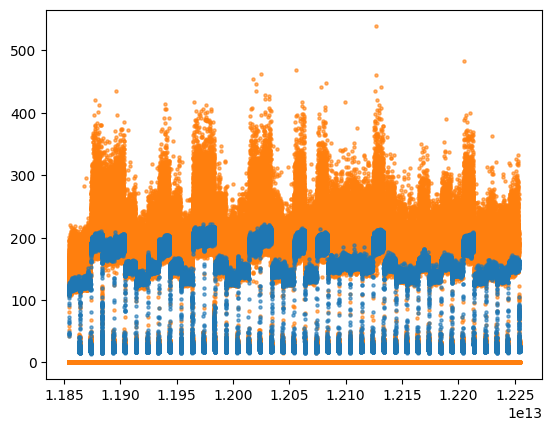

In [11]:
# this section intends to use a jumping window to split the observation into sections where we can observe if the sections are uniform.

# experiment info
with open('../data/E2-arrowlake-instructions/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
print(workloads)

workload_start = workloads[0]["start_ns"]
workload_end = workloads[-1]["end_ns"]

print(f"experiment duration: {workload_start} to {workload_end}, lasted {(workload_end - workload_start)/1000_000_000} s")


df_teensy_original = corrected_df
df_teensy_original["cpu_total"] = df_teensy_original["Y"] + df_teensy_original["Z"] + df_teensy_original["U"] + df_teensy_original["V"]
df_rapl_original = df_rapl_watt
print(df_teensy_original.columns) 
print(df_teensy_original.shape)
print(df_rapl_original.columns) 
print(df_rapl_original.shape)

df_teensy_1 = df_teensy_original.set_index("timestamp")
df_rapl_1 = df_rapl_original.set_index("timestamp")
df_merged_outer = pd.merge(df_teensy_1, df_rapl_1, left_index=True, right_index=True, how='outer')
print(df_merged_outer.head())

df_merged_outer = df_merged_outer[(df_merged_outer.index >= workload_start) & (df_merged_outer.index <= workload_end)]

# 1. Create a mask and Group IDs
is_not_nan = df_merged_outer['power'].notna()
group_id = is_not_nan.cumsum()

# 2. Count how many NaNs are in each group
# We only group the rows where 'a' was actually NaN
nan_counts = df_merged_outer[df_merged_outer['power'].isna()].groupby(group_id).size()

# 3. Include the "Zeroes"
# Some non-NaN values might have 0 NaNs following them.
# We reindex to include every group ID from 1 to the total count of non-NaNs.
total_non_nans = is_not_nan.sum()
all_gaps = nan_counts.reindex(np.arange(1, total_non_nans + 1), fill_value=0)

# 4. Final Statistics
stats = {
    'mean': all_gaps.mean(),
    'median': all_gaps.median(),
    'max': all_gaps.max(),
    'min': all_gaps.min()
}

print(stats)
all_gaps = all_gaps.sort_values(ascending = False)
#print(all_gaps.head())
plt.scatter(df_merged_outer.index, df_merged_outer["power"], s=5, color='tab:orange', alpha=0.6, label="rapl")
plt.scatter(df_merged_outer.index, df_merged_outer["cpu_total"], s=5, color='tab:blue', alpha=0.6, label="measured")
plt.show()


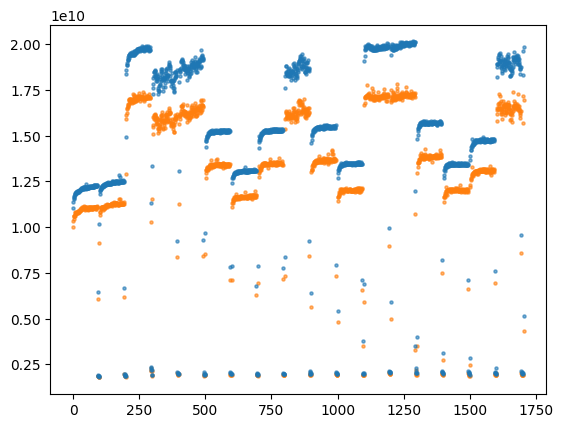

In [12]:
import pandas as pd
import numpy as np
from scipy.integrate import trapezoid

def integrate_dual_cadence(df, col1, col2, window = 10):
    # 1. Identify rows where 'a' is valid
    is_a_valid = df[col1].notna()
    
    # 2. Create Window IDs based on every 10 valid 'a' values
    # cumsum increments at every valid 'a', then // 10 groups them
    # We subtract 1 so the first group is 0
    a_group_id = (is_a_valid.cumsum() - 1) // window
    
    # 3. Handle Column B's range:
    # Column B needs to integrate everything from the first valid 'a' in the group
    # to just before the first 'a' of the NEXT group.
    # a_group_id naturally covers this range for every row.
    
    # 4. Define the integration logic
    def perform_integration(group):
        # -- Integration for A --
        # Filter only non-NaN a values
        a_data = group[col1].dropna()
        # Trapezoid needs at least 2 points to calculate area
        area_a = scipy.integrate.trapezoid(y=a_data.values, x=a_data.index, dx=1.0, axis=-1) if len(a_data) > 1 else 0
        
        # -- Integration for B --
        # Filter only non-NaN b values
        # This takes all rows in the 10-point 'a' window
        b_data = group[col2].dropna()
        area_b = scipy.integrate.trapezoid(y=b_data.values, x=b_data.index, dx=1.0, axis=-1) if len(b_data) > 1 else 0
        # print(a_data.index)
        # print(len(a_data.index))
        # print(b_data.index)
        # print(len(b_data.index))
        # print("break")

        return pd.Series({'area_a': area_a, 'area_b': area_b})

    # 5. Execute GroupBy
    # We only process groups where a_group_id >= 0 (ignores NaNs at the very start)
    results_df = df[a_group_id >= 0].groupby(a_group_id).apply(perform_integration)
    
    return results_df

# Example usage with dummy data
# df = pd.DataFrame({'a': [...], 'b': [...]})
integrated_results = integrate_dual_cadence(df_merged_outer.head(500000), "power", "cpu_total", window=100)

plt.scatter(integrated_results.index, integrated_results["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
plt.scatter(integrated_results.index, integrated_results["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
plt.show()

### Per-instruction-set energy samples


In [13]:
with open('../data/E2-arrowlake-instructions/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
#print(workloads)

samples_kw = []
for workload in workloads: 
    start_ns = workload["start_ns"]
    end_ns = workload["end_ns"]
    workload_name = workload["name"]
    samples_kw.append(df_merged_outer[(df_merged_outer.index > start_ns) & (df_merged_outer.index < end_ns)])

samples_integrals_kw = []
for sample in samples_kw: 
    samples_integrals_kw.append(integrate_dual_cadence(sample, "power", "cpu_total", window=100))

# for i, sample in enumerate(samples):
#     plt.scatter(samples_integrals[i].index, samples_integrals[i]["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
#     plt.scatter(samples_integrals[i].index, samples_integrals[i]["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
#     plt.show()

samples_by_workload_kw = {}
for i, workload in enumerate(workloads):
    if workload["name"] in samples_by_workload_kw.keys():
        df1 = samples_by_workload_kw[workload["name"]]
        df2 = samples_integrals_kw[i]
        samples_by_workload_kw[workload["name"]] = pd.concat([df1, df2], axis =0)
    else: 
        samples_by_workload_kw[workload["name"]] = samples_integrals_kw[i]
    # print(workload["name"])
    # print(samples_by_workload_kw[workload["name"]].shape)
    
for i, workload in enumerate(workloads):
    df1 = samples_by_workload_kw[workload["name"]]
    df1["diff"] = df1["area_a"] - df1["area_b"]
    df1["diff_normalized"] = df1["diff"] / df1["area_b"]

for i, sample in enumerate(list(samples_by_workload_kw.values())):
    print(type(sample))
    # plt.scatter(sample.index, sample["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
    # plt.scatter(sample.index, sample["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
    # plt.scatter(sample.index, sample["diff"], s=5, color='tab:green', alpha=0.6, label="diff")
    # plt.scatter(sample.index, sample["diff_normalized"], s=5, color='tab:red', alpha=0.6, label="diff normals")
    # plt.show()
    

    

#segments = [17398106102790, 17408115632950, 17418125344082, 17428134473623, 17438142474785, 17448150626666, 17458160825127, 17468168994269, 17478177946304,17488185946880, 17498193747238]

# plot_cpu_vs_energy(rapl_teensy_merged, sample_factor=100, time_col="timestamp", segments=segments)
# for i, workload in enumerate(workloads):
#     print(f"#{i}: {workload['name']}")



<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


### Normalized difference + orthogonal (TLS) regression


In [ ]:
# === Sensor-normalized difference + orthogonal (total least squares) regression ===
# area_a = RAPL energy per window ; area_b = measured (sensor) energy per window.
import numpy as np, pandas as pd
from scipy import odr, stats

_all   = pd.concat(list(samples_by_workload_kw.values()), axis=0)
rapl   = _all["area_a"].to_numpy(float)
sensor = _all["area_b"].to_numpy(float)
m = np.isfinite(rapl) & np.isfinite(sensor) & (sensor != 0)
rapl, sensor = rapl[m], sensor[m]
n = len(rapl)

# --- normalized difference, normalized to the SENSOR reading (not RAPL) ---
norm_diff = (rapl - sensor) / sensor
ci = stats.t.interval(0.95, n - 1, loc=norm_diff.mean(), scale=stats.sem(norm_diff))
print(f"n windows = {n}")
print("Normalized difference  (RAPL - Sensor) / Sensor :")
print(f"  mean   = {norm_diff.mean()*100:+.2f}%   median = {np.median(norm_diff)*100:+.2f}%")
print(f"  std    = {norm_diff.std(ddof=1)*100:.2f}%   IQR = "
      f"[{np.percentile(norm_diff,25)*100:+.2f}%, {np.percentile(norm_diff,75)*100:+.2f}%]")
print(f"  95% CI of mean = [{ci[0]*100:+.2f}%, {ci[1]*100:+.2f}%]")

# --- orthogonal regression (ODR / total least squares):  RAPL = slope * Sensor + intercept ---
def _lin(B, x): return B[0] * x + B[1]
b0, a0 = np.polyfit(sensor, rapl, 1)               # OLS guess
out = odr.ODR(odr.Data(sensor, rapl), odr.Model(_lin), beta0=[b0, a0]).run()
slope, intercept = out.beta
slope_se, intercept_se = out.sd_beta
r = np.corrcoef(sensor, rapl)[0, 1]
print("\nOrthogonal regression  RAPL = slope * Sensor + intercept :")
print(f"  slope     = {slope:.4f} +/- {slope_se:.4f}")
print(f"  intercept = {intercept:.3f} +/- {intercept_se:.3f}  (W*ns)")
print(f"  Pearson r = {r:.4f}    R^2 = {r**2:.4f}")
print(f"  residual variance (ODR) = {out.res_var:.4g}")
# deviation from the identity line RAPL == Sensor
print(f"  slope vs 1     : t = {(slope-1)/slope_se:+.2f}   (|t|>2 => proportional bias)")
print(f"  intercept vs 0 : t = {(intercept-0)/intercept_se:+.2f}   (|t|>2 => fixed offset bias)")


### Figure: energy per instruction set (absolute)


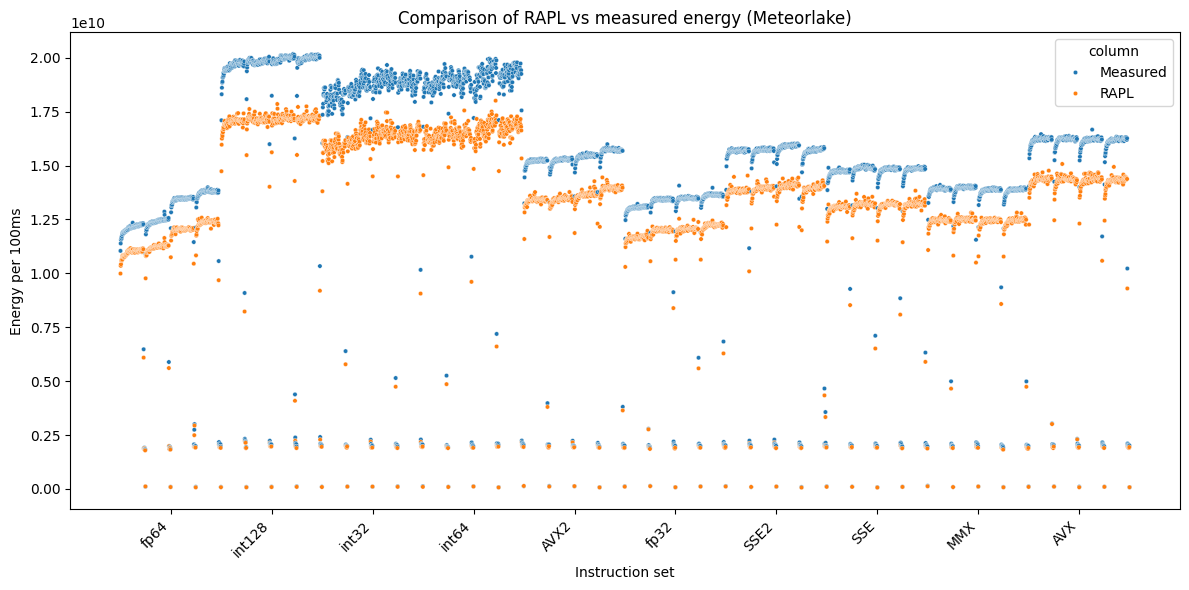

In [37]:
samples_by_workload_kw_display = {}
for key, df in samples_by_workload_kw.items():
    samples_by_workload_kw_display[key.split(':')[1]] = samples_by_workload_kw[key]



import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rows = []
x_pos = 0
group_centers = []
group_labels = []

for key, df in samples_by_workload_kw_display.items():

    n = len(df)

    xs = list(range(x_pos, x_pos + n))

    for x, (_, row) in zip(xs, df.iterrows()):
        rows.append({"x": x, "value": row["area_b"], "column": "Measured"})
        rows.append({"x": x, "value": row["area_a"], "column": "RAPL"})
       

    group_centers.append(x_pos + (n - 1) / 2)
    group_labels.append(key)

    x_pos += n + 1  # gap between groups

plot_df = pd.DataFrame(rows)

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=plot_df,
    x="x",
    y="value",
    hue="column",
    s=10,
    edgecolor="none",   # remove seaborn's default white marker rim
    linewidth=0,
)

plt.xticks(group_centers, group_labels, rotation=45, ha="right")
plt.xlabel("Instruction set")
plt.ylabel("Energy per 100ms")
plt.title("Comparison of RAPL vs measured energy (Meteorlake)")
plt.tight_layout()
plt.savefig(
    "meteorenergy.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()



### Figure: energy per instruction set (normalized to sensor)


In [ ]:
# normalized version of the RAPL-vs-measured plot: each observation divided by the sensor (Measured) reading
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

samples_by_workload_kw_display = {}
for key, df in samples_by_workload_kw.items():
    samples_by_workload_kw_display[key.split(':')[1]] = samples_by_workload_kw[key]

rows = []
x_pos = 0
group_centers = []
group_labels = []

for key, df in samples_by_workload_kw_display.items():
    n = len(df)
    xs = list(range(x_pos, x_pos + n))
    for x, (_, row) in zip(xs, df.iterrows()):
        rows.append({"x": x, "value": row["area_b"] / row["area_b"], "column": "Measured"})
        rows.append({"x": x, "value": row["area_a"] / row["area_b"], "column": "RAPL"})
    group_centers.append(x_pos + (n - 1) / 2)
    group_labels.append(key)
    x_pos += n + 1

plot_df = pd.DataFrame(rows)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=plot_df,
    x="x",
    y="value",
    hue="column",
    s=10,
    edgecolor="none",
    linewidth=0,
)
plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)  # sensor baseline
plt.xticks(group_centers, group_labels, rotation=45, ha="right")
plt.xlabel("Instruction set")
plt.ylabel("Energy normalized to sensor")
plt.title("RAPL vs measured energy, normalized to sensor (Meteorlake)")
plt.tight_layout()
plt.savefig("meteorenergy_normalized.svg", format="svg", bbox_inches="tight")
plt.show()


### Wilcoxon signed-rank on energy


In [17]:
# perform pairwise comparison for Energy data between RAPL and Teensy, using Wilconxon ranksum test

with open('../data/E2-arrowlake-instructions/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
#print(workloads)


# samples = []
# for workload in workloads: 
#     start_ns = workload["start_ns"]
#     end_ns = workload["end_ns"]
#     workload_name = workload["name"]
#     samples.append(rapl_teensy_merged[(rapl_teensy_merged["timestamp"] > start_ns) & (rapl_teensy_merged["timestamp"] < end_ns)])

# samples_by_workload = {}
# for i, workload in enumerate(workloads):
#     if workload["name"] in samples_by_workload.keys():
#         df1 = samples_by_workload[workload["name"]]
#         df2 = samples[i]
#         samples_by_workload[workload["name"]] = pd.concat([df1, df2], axis =0)
#     else: 
#         samples_by_workload[workload["name"]] = samples[i]
    # print(workload["name"])
    # print(samples_by_workload[workload["name"]].shape)

# no normalization for wilcoxon.    
# for i, workload in enumerate(workloads):
#     df1 = samples_by_workload[workload["name"]]
#     df1["diff"] = df1["power"] - df1["cpu_total"]
#     df1["diff_normalized"] = df1["diff"] / df1["cpu_total"] #use sensor measurement as base for normalization
 
# for i, sample in enumerate(list(samples_by_workload.values())):
#     print(type(sample))
#     # plt.scatter(sample.index, sample["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
#     # plt.scatter(sample.index, sample["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
#     # plt.scatter(sample.index, sample["diff"], s=5, color='tab:green', alpha=0.6, label="diff")
#     plt.scatter(sample.index, sample["diff_normalized"], s=5, color='tab:red', alpha=0.6, label="diff normals")
#     plt.show()

results = []
for i, sample in enumerate(samples_by_workload_kw.values()):
    result = run_tests(sample, xname="area_a", yname="area_b")
    result["workload name"] = list(samples_by_workload_kw.keys())[i].split(':')[1]
    results.append(result)
df_descriptive = pd.DataFrame(results)
df_descriptive['significance'] = np.where(df_descriptive['p twotail'] < 0.001, "p < 0.001", "ns")
#effect size interprept.
conditions = [
    df_descriptive["rank biserial effectsize"].abs() >= 0.5,
    df_descriptive["rank biserial effectsize"].abs() >= 0.3,
    df_descriptive["rank biserial effectsize"].abs() >= 0.1
]
#Labels
choices = ["Large", "Medium", "Small"]
df_descriptive['effectsize word'] = np.select(conditions, choices, default="Negligible")
# directionality 
conditions = [
    df_descriptive["rank biserial effectsize"] > 0, 
    df_descriptive["rank biserial effectsize"] == 0,
    df_descriptive["rank biserial effectsize"] < 0
]
choices = ["X is greater", "Equal", "X is smaller"]
df_descriptive['direction'] = np.select(conditions, choices, default="NA")
df_descriptive.to_csv("Energy_descriptive_statistics_wilcoxon_rank_biserial.csv", index=False)
# snippets = []
# results = []
# for i in range (0, len(segments) - 1): 
#     snippets.append(rapl_teensy_merged[(rapl_teensy_merged["timestamp"] >= segments[i]) & (rapl_teensy_merged["timestamp"] <= segments[i + 1])])
#     print(f"workload # {i}")
#     result = run_tests(snippets[i])
#     results.append(result)

# df_descriptive = pd.DataFrame(results)
# df_descriptive.to_csv("descriptive_statistics_wilcoxon.csv", index=False)


target_cols = ["p value"]


WilcoxonResult(statistic=np.float64(8.0), pvalue=np.float64(6.433342159469221e-68))
WilcoxonResult(statistic=np.float64(8.0), pvalue=np.float64(3.2166710797346107e-68))
WilcoxonResult(statistic=np.float64(8.0), pvalue=np.float64(1.0))
onesided Wilcoxon result: p value < threshold (ie, 0.05) means x is <alternative> than y
effectsize -0.6609646113126164
rB: 0: negligible effect, 0.1: small effect, 0.3: medium effect, 0.5: large effect
x median 11293617398.104969
y median 12480140754.2305
-1180371319.3606467
1180477111.686636
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(6.061596090070382e-68))
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(3.030798045035191e-68))
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(1.0))
onesided Wilcoxon result: p value < threshold (ie, 0.05) means x is <alternative> than y
effectsize -0.8335457308107048
rB: 0: negligible effect, 0.1: small effect, 0.3: medium effect, 0.5: large effect
x median 17127100520.64849
y medi